In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os

# Configurações de visualização
%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 5)

In [3]:
# Caminho raiz dos dados
data_root = Path('../data')  # sobe um nível para acessar data/

# Lista todos os arquivos .npz recursivamente
arquivos = sorted(data_root.glob('*/*.npz'))

print(f"Total de arquivos .npz encontrados: {len(arquivos)}")
print("\nPrimeiros 10 arquivos:")
for arq in arquivos[:10]:
    print(f"  {arq.relative_to(data_root)}")

Total de arquivos .npz encontrados: 161

Primeiros 10 arquivos:
  1730 RPM\1730_B_14_DE12.npz
  1730 RPM\1730_B_14_DE48.npz
  1730 RPM\1730_B_14_FE.npz
  1730 RPM\1730_B_21_DE12.npz
  1730 RPM\1730_B_21_DE48.npz
  1730 RPM\1730_B_21_FE.npz
  1730 RPM\1730_B_28_DE12.npz
  1730 RPM\1730_B_7_DE12.npz
  1730 RPM\1730_B_7_DE48.npz
  1730 RPM\1730_B_7_FE.npz


In [13]:
# Arquivo de falha: Inner Race, 0.007", DE 12 kHz
arquivo_falha = pasta_1797 / '1797_IR_7_DE12.npz'

# Carrega
dados_falha = np.load(arquivo_falha)
sinal_falha = dados_falha['DE'].flatten()

print(f"Sinal de falha (IR007) carregado: {len(sinal_falha)} pontos")
print(f"Duração: {len(sinal_falha)/fs:.2f} segundos")

Sinal de falha (IR007) carregado: 121265 pontos
Duração: 10.11 segundos


In [9]:
# Ajuste do caminho: a pasta agora é '1797 RPM' (com espaço)
pasta_1797 = data_root / '1797 RPM'

# Arquivo normal
arquivo_normal = pasta_1797 / '1797_Normal.npz'

# Carrega o arquivo
dados_normal = np.load(arquivo_normal)

# Extrai o sinal DE (drive end)
sinal_normal = dados_normal['DE']
fs = 12000  # 12 kHz

print(f"Sinal normal carregado: {len(sinal_normal)} pontos")
print(f"Duração: {len(sinal_normal)/fs:.2f} segundos")

Sinal normal carregado: 243938 pontos
Duração: 20.33 segundos


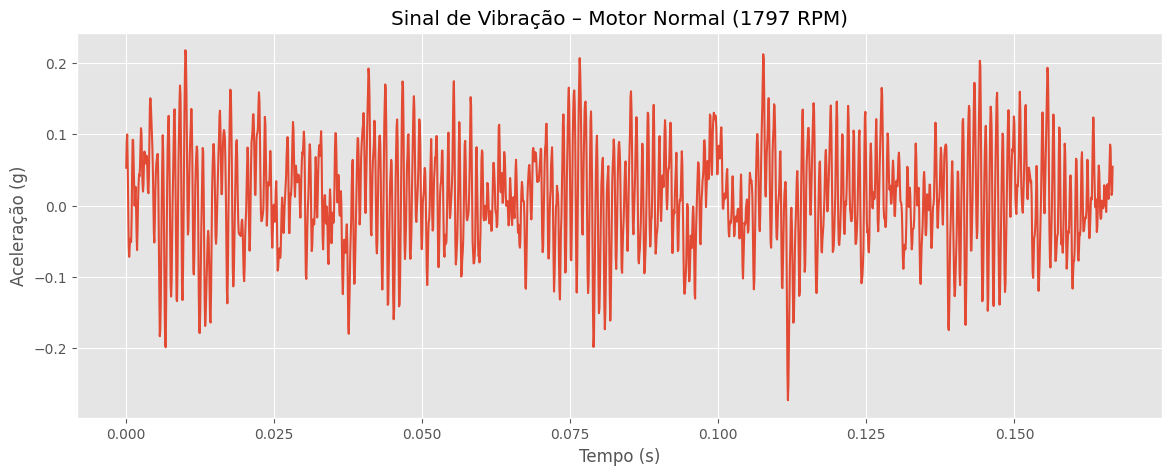

In [10]:
# Criar eixo do tempo
tempo = np.arange(0, len(sinal_normal)) / fs

# Pegar só os primeiros 2000 pontos para o gráfico
amostras_plot = 2000

plt.plot(tempo[:amostras_plot], sinal_normal[:amostras_plot])
plt.title('Sinal de Vibração – Motor Normal (1797 RPM)')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (g)')
plt.grid(True)
plt.show()

In [11]:
# Lista arquivos de Inner Race a 1797 RPM
arquivos_ir = sorted(pasta_1797.glob('*IR*'))
print("Arquivos de Inner Race disponíveis:")
for arq in arquivos_ir:
    print(f"  {arq.name}")

Arquivos de Inner Race disponíveis:
  1797_IR_14_DE12.npz
  1797_IR_14_DE48.npz
  1797_IR_14_FE.npz
  1797_IR_21_DE12.npz
  1797_IR_21_DE48.npz
  1797_IR_21_FE.npz
  1797_IR_28_DE12.npz
  1797_IR_7_DE12.npz
  1797_IR_7_DE48.npz
  1797_IR_7_FE.npz


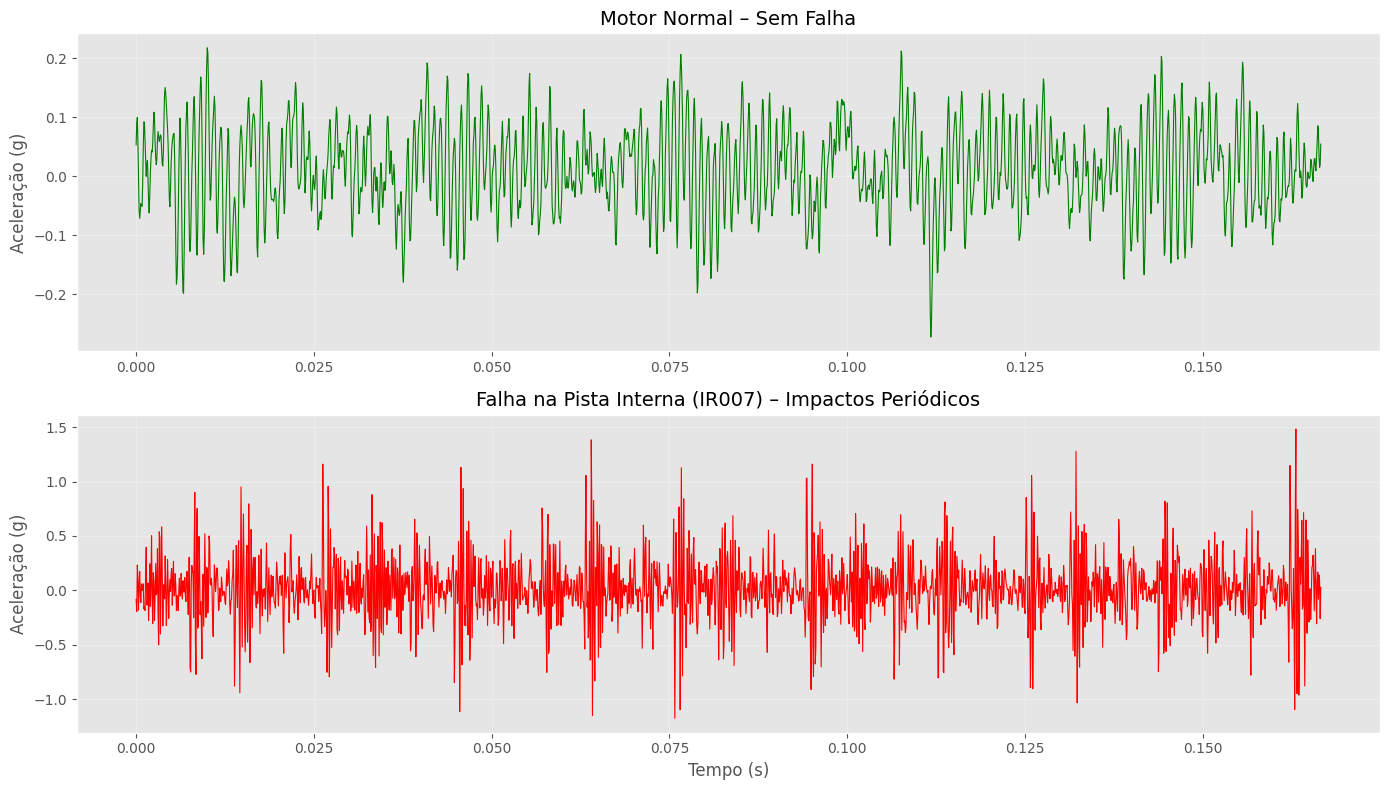

In [14]:
# Criar eixo do tempo (mesmo fs=12000)
tempo = np.arange(0, len(sinal_normal)) / fs

# Plot comparativo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Sinal normal
ax1.plot(tempo[:2000], sinal_normal[:2000], color='green', linewidth=0.8)
ax1.set_title('Motor Normal – Sem Falha', fontsize=14)
ax1.set_ylabel('Aceleração (g)')
ax1.grid(True, alpha=0.3)

# Sinal com falha
ax2.plot(tempo[:2000], sinal_falha[:2000], color='red', linewidth=0.8)
ax2.set_title('Falha na Pista Interna (IR007) – Impactos Periódicos', fontsize=14)
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Aceleração (g)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
from scipy import stats

def extrair_caracteristicas(sinal, fs=12000):
    n = len(sinal)
    
    # --- Domínio do tempo ---
    rms = np.sqrt(np.mean(sinal**2))
    kurtosis = stats.kurtosis(sinal)
    skewness = stats.skew(sinal)
    pico = np.max(np.abs(sinal))
    fator_crista = pico / (rms + 1e-10)
    
    # --- Domínio da frequência (garantindo tamanhos iguais) ---
    # Usamos rfft (espectro unilateral) e rfftfreq
    magnitude = np.abs(np.fft.rfft(sinal))
    frequencias = np.fft.rfftfreq(n, d=1/fs)
    
    # Asseguramos que tenham o mesmo comprimento (caso haja arredondamento)
    min_len = min(len(magnitude), len(frequencias))
    magnitude = magnitude[:min_len]
    frequencias = frequencias[:min_len]
    
    idx_pico = np.argmax(magnitude)
    freq_dominante = frequencias[idx_pico]
    
    # Energia em bandas
    energia_baixa = np.sum(magnitude[(frequencias >= 0) & (frequencias < 1000)])
    energia_media = np.sum(magnitude[(frequencias >= 1000) & (frequencias < 3000)])
    energia_alta = np.sum(magnitude[(frequencias >= 3000) & (frequencias < 6000)])
    
    return {
        'rms': rms,
        'kurtosis': kurtosis,
        'skewness': skewness,
        'pico': pico,
        'fator_crista': fator_crista,
        'freq_dominante': freq_dominante,
        'energia_baixa': energia_baixa,
        'energia_media': energia_media,
        'energia_alta': energia_alta
    }

In [22]:
janela_normal = sinal_normal[0:1024]
features_normal = extrair_caracteristicas(janela_normal)

janela_falha = sinal_falha[0:1024]
features_falha = extrair_caracteristicas(janela_falha)

df_comparacao = pd.DataFrame([features_normal, features_falha], 
                              index=['Normal', 'IR007'])
df_comparacao.T

,Normal,IR007
rms,0.075982,0.293202
kurtosis,[-0.24366426455323964],2.245145
skewness,[-0.16297611297662787],0.076467
pico,0.217794,1.382973
fator_crista,2.866393,4.716791
freq_dominante,1406.25,3585.9375
energia_baixa,5.694157,285.457753
energia_media,12.941873,1372.43557
energia_alta,13.780298,1228.561564


In [31]:
import re

def classificar_arquivo(nome_arquivo):
    nome = nome_arquivo.stem
    
    if 'Normal' in nome:
        return 'Normal', '0'
    
    # Expressão regular para capturar: tipo (IR/OR/B), severidade (7,14,21,28)
    # Ignora o @XX se existir (ex: OR@12_7_DE12)
    match = re.search(r'(IR|OR|B).*?(\d+)_DE12', nome)
    if match:
        tipo = match.group(1)           # 'IR', 'OR' ou 'B'
        sever_str = match.group(2)      # '7', '14', '21', '28'
        try:
            sever = int(sever_str)
            sever_formatada = f"{sever/1000:.3f}"
        except:
            sever_formatada = '0'
        classe = f"{tipo}{sever_str.zfill(3)}"  # ex: 'OR014'
        return classe, sever_formatada
    
    return nome, '0'

In [33]:
# Define pasta_1797 (se ainda não estiver definida)
pasta_1797 = data_root / '1797 RPM'

# Lista apenas arquivos DE12 (Drive End a 12 kHz)
arquivos_de12 = sorted(pasta_1797.glob('*DE12.npz'))

print(f"Total de arquivos DE12 a 1797 RPM: {len(arquivos_de12)}")
for arq in arquivos_de12:
    print(f"  {arq.name}")

Total de arquivos DE12 a 1797 RPM: 15
  1797_B_14_DE12.npz
  1797_B_21_DE12.npz
  1797_B_28_DE12.npz
  1797_B_7_DE12.npz
  1797_IR_14_DE12.npz
  1797_IR_21_DE12.npz
  1797_IR_28_DE12.npz
  1797_IR_7_DE12.npz
  1797_OR@12_21_DE12.npz
  1797_OR@12_7_DE12.npz
  1797_OR@3_21_DE12.npz
  1797_OR@3_7_DE12.npz
  1797_OR@6_14_DE12.npz
  1797_OR@6_21_DE12.npz
  1797_OR@6_7_DE12.npz


In [35]:
# Inclui arquivos DE12 e o Normal
arquivos_de12 = sorted(pasta_1797.glob('*DE12.npz'))
arquivo_normal = pasta_1797 / '1797_Normal.npz'
if arquivo_normal.exists():
    arquivos_de12.insert(0, arquivo_normal)

print("Arquivos selecionados:")
for arq in arquivos_de12:
    print(f"  {arq.name}")

Arquivos selecionados:
  1797_Normal.npz
  1797_B_14_DE12.npz
  1797_B_21_DE12.npz
  1797_B_28_DE12.npz
  1797_B_7_DE12.npz
  1797_IR_14_DE12.npz
  1797_IR_21_DE12.npz
  1797_IR_28_DE12.npz
  1797_IR_7_DE12.npz
  1797_OR@12_21_DE12.npz
  1797_OR@12_7_DE12.npz
  1797_OR@3_21_DE12.npz
  1797_OR@3_7_DE12.npz
  1797_OR@6_14_DE12.npz
  1797_OR@6_21_DE12.npz
  1797_OR@6_7_DE12.npz


In [36]:
for arq in arquivos_de12:
    classe, severidade = classificar_arquivo(arq)
    print(f"{arq.name:30s} -> Classe: {classe:8s} Severidade: {severidade}")

1797_Normal.npz                -> Classe: Normal   Severidade: 0
1797_B_14_DE12.npz             -> Classe: B014     Severidade: 0.014
1797_B_21_DE12.npz             -> Classe: B021     Severidade: 0.021
1797_B_28_DE12.npz             -> Classe: B028     Severidade: 0.028
1797_B_7_DE12.npz              -> Classe: B007     Severidade: 0.007
1797_IR_14_DE12.npz            -> Classe: IR014    Severidade: 0.014
1797_IR_21_DE12.npz            -> Classe: IR021    Severidade: 0.021
1797_IR_28_DE12.npz            -> Classe: IR028    Severidade: 0.028
1797_IR_7_DE12.npz             -> Classe: IR007    Severidade: 0.007
1797_OR@12_21_DE12.npz         -> Classe: OR021    Severidade: 0.021
1797_OR@12_7_DE12.npz          -> Classe: OR007    Severidade: 0.007
1797_OR@3_21_DE12.npz          -> Classe: OR021    Severidade: 0.021
1797_OR@3_7_DE12.npz           -> Classe: OR007    Severidade: 0.007
1797_OR@6_14_DE12.npz          -> Classe: OR014    Severidade: 0.014
1797_OR@6_21_DE12.npz          -> Clas

In [37]:
# Parâmetros da janela
WINDOW_SIZE = 1024   # tamanho da janela em pontos
STEP = 1024          # passo (sem sobreposição)

# Lista para acumular as linhas do DataFrame
todas_linhas = []

print("Processando arquivos...")
for arq in arquivos_de12:
    # Carrega o sinal DE
    dados = np.load(arq)
    sinal = dados['DE'].flatten()
    
    # Classifica o arquivo para obter metadados
    classe, severidade = classificar_arquivo(arq)
    
    # Determina o tipo de falha (Normal, IR, OR, B)
    if classe == 'Normal':
        tipo_falha = 'Normal'
    else:
        tipo_falha = classe[:2]  # 'IR', 'OR' ou 'B'
    
    # Percorre o sinal em janelas deslizantes
    for inicio in range(0, len(sinal) - WINDOW_SIZE + 1, STEP):
        janela = sinal[inicio:inicio + WINDOW_SIZE]
        
        # Extrai características
        feat = extrair_caracteristicas(janela)
        
        # Adiciona os metadados
        feat['classe'] = classe
        feat['tipo_falha'] = tipo_falha
        feat['severidade'] = severidade
        feat['arquivo'] = arq.name
        
        todas_linhas.append(feat)

# Cria o DataFrame
df = pd.DataFrame(todas_linhas)

# Mostra informações
print(f"\nDataFrame criado com sucesso!")
print(f"Shape: {df.shape}")
print(f"Classes únicas: {df['classe'].nunique()}")
print(f"\nDistribuição das classes:")
print(df['classe'].value_counts().sort_index())
print(f"\nPrimeiras 5 linhas:")
df.head()

Processando arquivos...

DataFrame criado com sucesso!
Shape: (2013, 13)
Classes únicas: 12

Distribuição das classes:
classe
B007      119
B014      118
B021      119
B028      117
IR007     118
IR014     118
IR021     119
IR028     117
Normal    238
OR007     357
OR014     118
OR021     355
Name: count, dtype: int64

Primeiras 5 linhas:


,rms,kurtosis,skewness,pico,fator_crista,freq_dominante,energia_baixa,energia_media,energia_alta,classe,tipo_falha,severidade,arquivo
0,0.075982,-0.243664,-0.162976,0.217794,2.866393,1066.40625,243.209977,210.025431,32.773579,Normal,Normal,0,1797_Normal.npz
1,0.070425,0.184817,-0.107386,0.272869,3.874580,1031.25000,234.363194,194.932264,44.211868,Normal,Normal,0,1797_Normal.npz
2,0.078377,-0.376182,0.050329,0.212370,2.709618,1031.25000,217.606977,220.961644,34.518520,Normal,Normal,0,1797_Normal.npz
3,0.079688,-0.034564,-0.163588,0.226765,2.845658,1031.25000,276.997938,215.098687,26.413369,Normal,Normal,0,1797_Normal.npz
4,0.076104,-0.321609,-0.028448,0.188588,2.478048,1031.25000,239.573522,224.663455,33.513065,Normal,Normal,0,1797_Normal.npz


In [38]:
# Cria a pasta data/processed se não existir
Path('../data/processed').mkdir(parents=True, exist_ok=True)

# Salva o CSV
df.to_csv('../data/processed/features_cwru.csv', index=False)
print("DataFrame salvo em data/processed/features_cwru.csv")

DataFrame salvo em data/processed/features_cwru.csv
